In [2]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('male_players.csv')
print(df.shape)
print(df.head())

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 2.4 MB/s eta 0:00:00a 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 2.4 MB/s eta 0:00:00a 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Matplotlib is building the font cache; this may take a moment.


(180021, 109)
   player_id                             player_url  fifa_version  \
0     231747    /player/231747/kylian-mbappe/240002          24.0   
1     239085   /player/239085/erling-haaland/240002          24.0   
2     192985  /player/192985/kevin-de-bruyne/240002          24.0   
3     158023     /player/158023/lionel-messi/240002          24.0   
4     165153    /player/165153/karim-benzema/240002          24.0   

   fifa_update update_as_of    short_name                       long_name  \
0          2.0   2023-09-22     K. Mbappé            Kylian Mbappé Lottin   
1          2.0   2023-09-22    E. Haaland            Erling Braut Haaland   
2          2.0   2023-09-22  K. De Bruyne                 Kevin De Bruyne   
3          2.0   2023-09-22      L. Messi  Lionel Andrés Messi Cuccittini   
4          2.0   2023-09-22    K. Benzema                   Karim Benzema   

  player_positions  overall  potential  ...   ldm   cdm   rdm   rwb    lb  \
0           ST, LW       91    

/var/folders/8k/ppw0_sfn3jz_q5lw0jlxr0nw0000gp/T/ipykernel_75237/2670888201.py:9: DtypeWarning: Columns (0: gk) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('male_players.csv')


In [3]:
print(df['fifa_version'].unique())
print(df['fifa_version'].value_counts().sort_index())


[24. 23. 22. 21. 20. 19. 18. 17. 16. 15.]
fifa_version
15.0    16182
16.0    16706
17.0    17596
18.0    17954
19.0    18086
20.0    18483
21.0    18892
22.0    19239
23.0    18533
24.0    18350
Name: count, dtype: int64


In [4]:
print(df.columns.tolist())

['player_id', 'player_url', 'fifa_version', 'fifa_update', 'update_as_of', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'club_team_id', 'club_name', 'league_id', 'league_name', 'league_level', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined_date', 'club_contract_valid_until_year', 'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'player_traits', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed'

In [5]:
cols = ['player_id', 'short_name', 'fifa_version', 'overall', 'potential',
        'value_eur', 'wage_eur', 'age', 'player_positions', 'club_name',
        'league_name', 'league_level', 'nationality_name', 'preferred_foot',
        'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

df_clean = df[cols].copy()

print(df_clean.isnull().sum())
print("\nTotal rows:", len(df_clean))


player_id               0
short_name              0
fifa_version            0
overall                 0
potential               0
value_eur            2153
wage_eur             1848
age                     0
player_positions        0
club_name            1865
league_name          1865
league_level         2250
nationality_name        0
preferred_foot          0
pace                20024
shooting            20024
passing             20024
dribbling           20024
defending           20024
physic              20024
dtype: int64

Total rows: 180021


In [6]:
missing_pace = df_clean[df_clean['pace'].isnull()]
print(missing_pace['player_positions'].value_counts().head(10))

player_positions
GK    20024
Name: count, dtype: int64


In [12]:
## removed goalkeepers - they have different stats so cant compare to outfield players
## removed players with no value/club listed - prob free agents, not useful for this analysis


In [13]:
df_clean = df_clean[df_clean['player_positions'] != 'GK'].copy()

df_clean = df_clean.dropna(subset=['value_eur', 'club_name'])

print(df_clean.isnull().sum())
print("\nTotal rows after cleaning:", len(df_clean))

player_id             0
short_name            0
fifa_version          0
overall               0
potential             0
value_eur             0
wage_eur              0
age                   0
player_positions      0
club_name             0
league_name           0
league_level        344
nationality_name      0
preferred_foot        0
pace                  0
shooting              0
passing               0
dribbling             0
defending             0
physic                0
dtype: int64

Total rows after cleaning: 158112


In [14]:
# cleaned data - down to 158112 rows from 180021 
# only league_level still has missing values (344) - small enough to just drop or ignore for now

In [15]:
df_clean = df_clean.dropna(subset=['league_level'])
print("Final clean rows:", len(df_clean))
print(df_clean.isnull().sum().sum(), "total missing values left")

Final clean rows: 157768
0 total missing values left


In [16]:
# fully cleaned - 157768 rows, 0 missing values
#  SQL / actual analysis left

In [17]:
conn = sqlite3.connect('football.db')
df_clean.to_sql('players', conn, if_exists='replace', index=False)

print("Database created!")
print(pd.read_sql("SELECT COUNT(*) as total_validation FROM players", conn))

Database created!
   total_validation
0            157768


In [19]:
#created sqlite db from cleaned data
#verified row count matches what we expect (157768) 

In [20]:
query1 = """
SELECT league_name, 
       ROUND(AVG(overall), 1) as avg_rating,
       COUNT(*) as num_players
FROM players
WHERE fifa_version = 24
GROUP BY league_name
ORDER BY avg_rating DESC
LIMIT 10
"""

result1 = pd.read_sql(query1, conn)
print(result1)

        league_name  avg_rating  num_players
0           La Liga        73.4          526
1    Premier League        73.1          600
2           Serie A        72.7          749
3           Ligue 1        71.5          441
4      Fortuna Liga        71.5           71
5             NB I.        69.7           26
6        Bundesliga        69.4          749
7            1. HNL        69.0           49
8     Liga Portugal        68.8          440
9  Liga Profesional        68.0          737


In [23]:
# Q1 done - top leagues by avg rating: La Liga, Premier League, Serie A (matches what id expect as biggest leagues)
# some smaller leagues like Fortuna Liga sneaking in high too - small sample size though (only 71 players)

In [24]:
query2 = """
SELECT player_positions,
       ROUND(AVG(overall), 1) as avg_rating,
       ROUND(AVG(value_eur), 0) as avg_value,
       COUNT(*) as num_players
FROM players
WHERE fifa_version = 24
GROUP BY player_positions
ORDER BY avg_value DESC
LIMIT 15
"""

result2 = pd.read_sql(query2, conn)
print(result2)

   player_positions  avg_rating    avg_value  num_players
0        LW, CF, ST        86.0  102500000.0            1
1            CF, LW        78.8   37725000.0            4
2       LM, CF, CAM        82.0   29500000.0            1
3        CF, LM, ST        73.5   29012500.0            2
4       CF, CAM, ST        74.5   25700000.0            4
5       CDM, RB, CM        71.5   22868750.0            4
6        LW, CF, LM        81.0   22750000.0            2
7        RM, CM, RB        75.5   21850000.0            2
8        CF, LW, ST        73.0   21437500.0            2
9        CM, LM, RB        79.0   20000000.0            1
10       CF, ST, LW        74.0   19737500.0            4
11           CM, RW        67.9   16838929.0           14
12      CAM, RW, ST        68.7   15941667.0            3
13       RB, LB, LM        77.0   15500000.0            1
14       CF, RW, RM        83.0   15500000.0            1


In [25]:
# Q2 attempt - positions are messy, too many combos like "LW, CF, ST" with only 1-4 players
# need to simplify to just the PRIMARY position to compare properly

In [26]:
# Extract just the primary (first) position
df_clean['primary_position'] = df_clean['player_positions'].str.split(',').str[0]

# Reload into the database with this new column
df_clean.to_sql('players', conn, if_exists='replace', index=False)

print(df_clean['primary_position'].value_counts())

primary_position
CB     30304
ST     25358
CM     20941
CDM    14197
RB     12814
LB     12712
CAM    10770
LM      9916
RM      9866
RW      3961
LW      3669
CF      1116
RWB     1078
LWB     1065
GK         1
Name: count, dtype: int64


In [27]:
# fixed positions - now using primary position only, much cleaner
# CB is most common position (30304), makes sense - every team needs defenders
# 1 GK snuck through somehow - tiny number, not worth worrying about

In [28]:
query2 = """
SELECT primary_position,
       ROUND(AVG(overall), 1) as avg_rating,
       ROUND(AVG(value_eur), 0) as avg_value,
       COUNT(*) as num_players
FROM players
WHERE fifa_version = 24 AND primary_position != 'GK'
GROUP BY primary_position
ORDER BY avg_value DESC
"""

result2 = pd.read_sql(query2, conn)
print(result2)

   primary_position  avg_rating  avg_value  num_players
0                CF        70.2  8280962.0          130
1                LW        66.5  5379672.0          411
2                RW        66.0  4043459.0          451
3               CAM        65.9  3376270.0         1043
4                CM        65.7  3214963.0         2189
5               CDM        66.7  3059159.0         1511
6                ST        65.8  2950775.0         2446
7                RM        65.9  2762157.0          939
8                CB        66.3  2677831.0         3244
9                LM        65.9  2598889.0          954
10               LB        65.7  2515974.0         1155
11               RB        65.8  2395789.0         1179
12              RWB        64.6  1885100.0          300
13              LWB        64.4  1803491.0          265


In [29]:
# Q2 results - CF has way higher avg value than rating would suggest (8.28M for 70.2 rating)
# wingers (LW/RW) also valued higher than midfielders despite similar ratings
# fullbacks (RWB/LWB/RB/LB) lowest value across the board

In [30]:
query3 = """
SELECT 
    ROUND(AVG(pace), 1) as avg_pace,
    ROUND(AVG(shooting), 1) as avg_shooting,
    ROUND(AVG(passing), 1) as avg_passing,
    ROUND(AVG(dribbling), 1) as avg_dribbling,
    ROUND(AVG(defending), 1) as avg_defending,
    ROUND(AVG(physic), 1) as avg_physic
FROM players
WHERE fifa_version = 24
"""

result3 = pd.read_sql(query3, conn)
print(result3)

   avg_pace  avg_shooting  avg_passing  avg_dribbling  avg_defending  \
0      68.4          52.6         57.5           62.8           52.1   

   avg_physic  
0        64.9  


In [31]:
attributes = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
correlations = df_clean[df_clean['fifa_version']==24][attributes + ['overall']].corr()['overall'].sort_values(ascending=False)
print(correlations)

overall      1.000000
passing      0.713552
dribbling    0.658326
physic       0.532787
shooting     0.479238
defending    0.356477
pace         0.175300
Name: overall, dtype: float64


In [32]:
# interesting - pace has highest avg stat but LOWEST correlation with overall rating (0.18)
# passing and dribbling matter way more to rating than i expected (0.71 and 0.66)
# makes sense actually - skill/technique matters more than raw speed for being "good" overall

In [33]:
# Which clubs get best value for money (high rating, lower cost)?
query4 = """
SELECT club_name,
       ROUND(AVG(overall), 1) as avg_rating,
       ROUND(AVG(value_eur), 0) as avg_value,
       COUNT(*) as squad_size
FROM players
WHERE fifa_version = 24
GROUP BY club_name
HAVING squad_size >= 15
ORDER BY avg_rating DESC, avg_value ASC
LIMIT 10
"""

result4 = pd.read_sql(query4, conn)
print(result4)

             club_name  avg_rating   avg_value  squad_size
0                Inter        80.3  28568182.0          22
1    FC Bayern München        79.4  43201190.0          21
2  Paris Saint Germain        78.9  34185185.0          27
3      Manchester City        78.2  42340000.0          25
4           RB Leipzig        77.8  21363636.0          22
5               Napoli        77.7  26738043.0          23
6           Villarreal        77.4  13427273.0          22
7    Borussia Dortmund        77.2  20640000.0          25
8             Juventus        77.2  21214286.0          21
9                Milan        77.2  23283333.0          24


In [35]:
# Q4 - top clubs by rating: Inter, Bayern, PSG, Man City - matches real world 
# Villarreal interesting - high rating (77.4) but way lower avg value (13.4M) vs similar-rated clubs

In [36]:
query5 = """
SELECT fifa_version,
       ROUND(AVG(value_eur), 0) as avg_value,
       ROUND(AVG(overall), 1) as avg_rating
FROM players
GROUP BY fifa_version
ORDER BY fifa_version
"""

result5 = pd.read_sql(query5, conn)
print(result5)

   fifa_version  avg_value  avg_rating
0          15.0  1091552.0        63.9
1          16.0  1726969.0        65.5
2          17.0  2001264.0        66.3
3          18.0  2506974.0        66.4
4          19.0  2533728.0        66.3
5          20.0  2572183.0        66.3
6          21.0  2988112.0        65.8
7          22.0  2965082.0        65.9
8          23.0  2967657.0        66.0
9          24.0  2962576.0        66.0


In [37]:
# Q5 - value went from 1.09M to 2.96M (almost 3x) from 2015 to 2024
# but avg rating barely changed (63.9 to 66.0)
# means market value inflation isnt really about players getting better - more like transfer market/economics changing

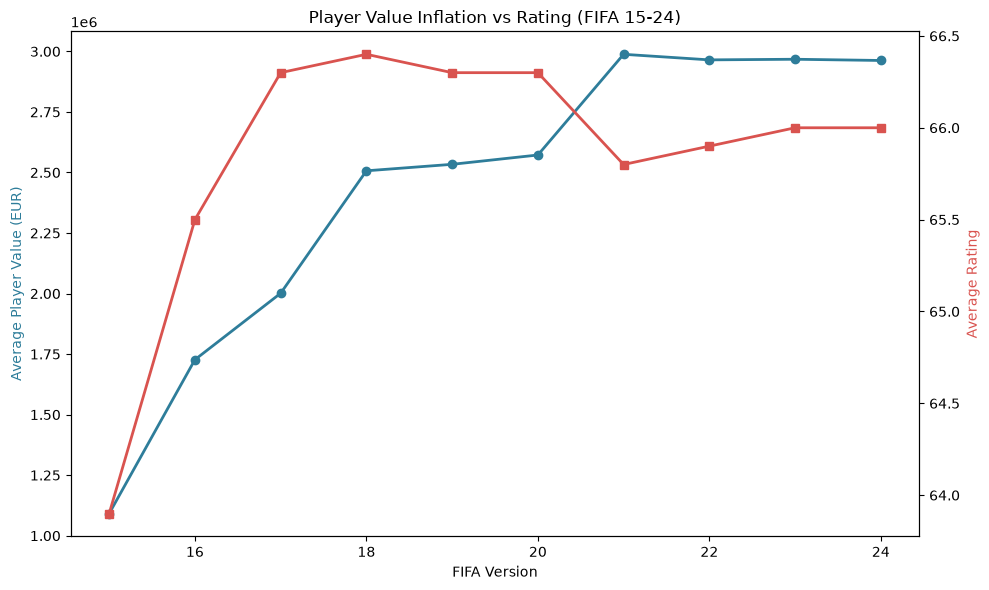

In [38]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(result5['fifa_version'], result5['avg_value'], marker='o', color='#2E7D9A', linewidth=2)
ax1.set_xlabel('FIFA Version')
ax1.set_ylabel('Average Player Value (EUR)', color='#2E7D9A')
ax1.set_title('Player Value Inflation vs Rating (FIFA 15-24)')

ax2 = ax1.twinx()
ax2.plot(result5['fifa_version'], result5['avg_rating'], marker='s', color='#D9534F', linewidth=2)
ax2.set_ylabel('Average Rating', color='#D9534F')

plt.tight_layout()
plt.savefig('value_vs_rating.png', dpi=150)
plt.show()

In [40]:
# chart looks good - value keeps climbing but rating plateaus/dips around year 20-21
# lines actually cross visually - good way to SHOW the disconnect

/var/folders/8k/ppw0_sfn3jz_q5lw0jlxr0nw0000gp/T/ipykernel_75237/883722571.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result2.sort_values('avg_value', ascending=False),


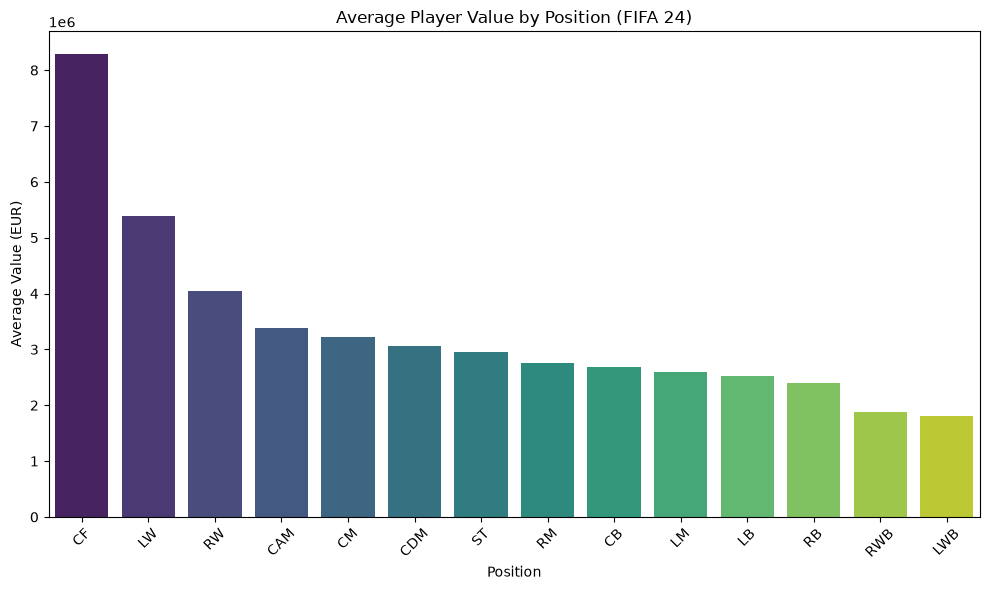

In [41]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=result2.sort_values('avg_value', ascending=False), 
            x='primary_position', y='avg_value', palette='viridis')
plt.title('Average Player Value by Position (FIFA 24)')
plt.xlabel('Position')
plt.ylabel('Average Value (EUR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('position_value.png', dpi=150)
plt.show()

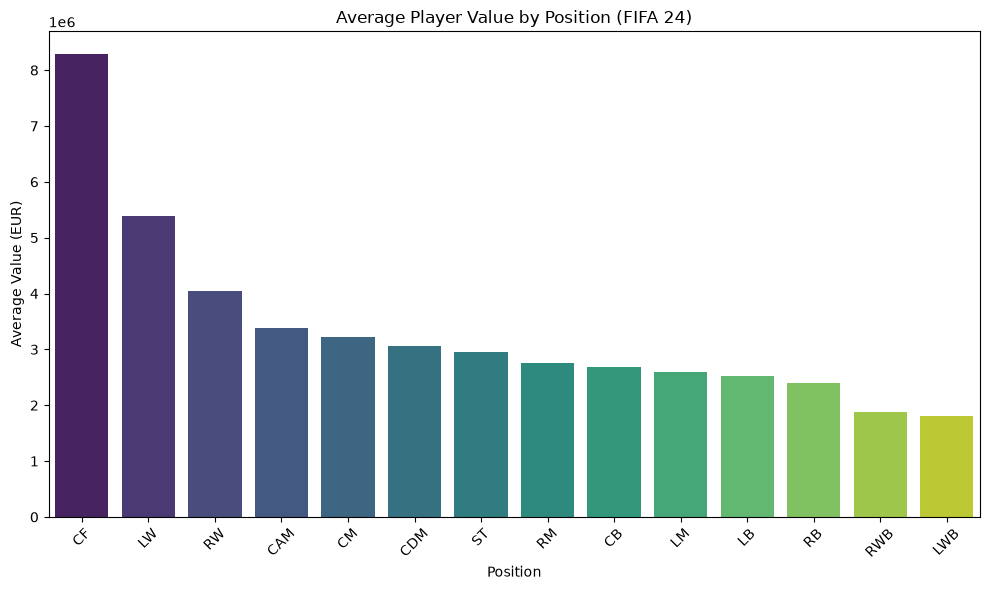

In [42]:
plt.figure(figsize=(10, 6))
sns.barplot(data=result2.sort_values('avg_value', ascending=False), 
            x='primary_position', y='avg_value', hue='primary_position', 
            palette='viridis', legend=False)
plt.title('Average Player Value by Position (FIFA 24)')
plt.xlabel('Position')
plt.ylabel('Average Value (EUR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('position_value.png', dpi=150)
plt.show()


In [45]:
# position value chart looks great - CF way higher than everything else
# clear visual pattern: attacking positions (CF/LW/RW) >> defensive positions (RWB/LWB)
# this chart alone shows the trend clearly

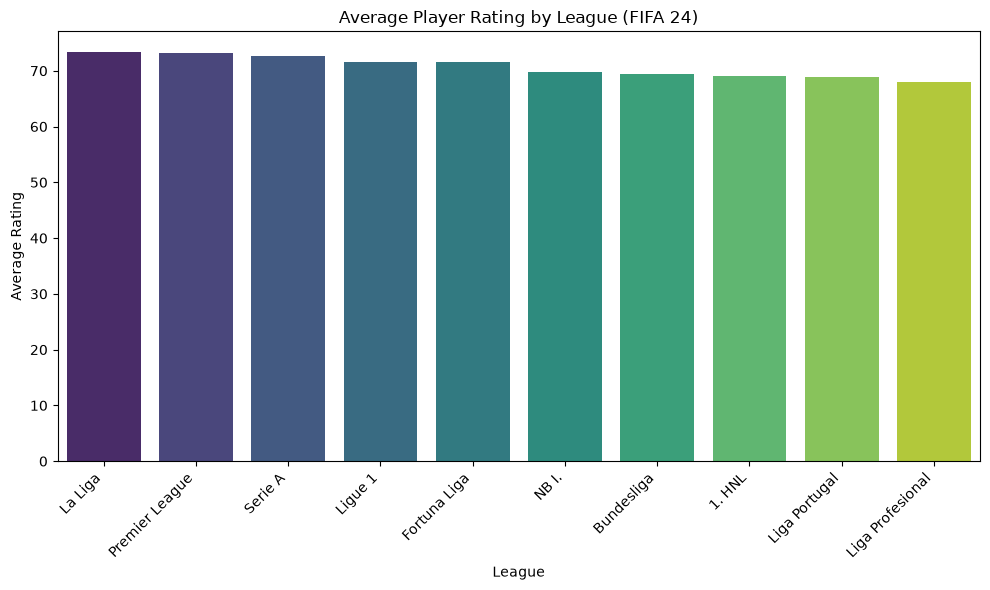

In [46]:
plt.figure(figsize=(10, 6))
sns.barplot(data=result1.sort_values('avg_rating', ascending=False), 
            x='league_name', y='avg_rating', hue='league_name',
            palette='viridis', legend=False)
plt.title('Average Player Rating by League (FIFA 24)')
plt.xlabel('League')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('league_rating.png', dpi=150)
plt.show()

In [48]:
# leagues chart done - confirms La Liga/Premier League/Serie A on top
# gap between top leagues and rest isnt huge actually (73 vs 68) - closer than i expected
# Not as usefully to undertsnad visually as numbers are very close makes diffrence see less severe than it is.

In [53]:
## Summary

# I analyzed 157,768 FIFA player records spanning 10 years (FIFA 15 to FIFA 24) to explore
# whether player ratings actually predict market value, and what factors really drive a
# player's worth in the data.

### Key findings
# Attacking positions (CF, LW, RW) are valued way higher than their ratings alone would suggest, while defensive positions (fullbacks especially) are undervalued relative to skill
# Passing and dribbling correlate much more strongly with overall rating than pace does - technical skill matters more than raw speed
# Player market values almost tripled from 2015 to 2024, but average ratings barely moved - meaning the football market has inflated independent of actual player quality improving
# Top leagues (La Liga, Premier League, Serie A) lead in average rating, but the gap between top and bottom leagues is smaller than expected (5 points)

### What I learned
# Going through this project taught me the full data analysis process - cleaning messy real-world data, writing SQL queries to answer specific questions, and building visualizations that actually communicate a finding clearly.